In [20]:
# importing library


import matplotlib.pyplot as plt
import osmnx as ox
import json
import overpass

In [4]:
# getting a city 
city = "Las Piñas, Metro Manila"

In [5]:
type(city)

str

In [6]:
# taking boundary for the location from a city
boundary = ox.geocode_to_gdf(city)

In [7]:
# printing to the screen
boundary

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((120.94335 14.49391, 120.96889 14.476...",120.943353,14.349186,121.024204,14.501115,259066622,relation,2095594,14.480901,120.981786,boundary,administrative,12,0.502218,city,Las Piñas,"Las Piñas, Southern Manila District, Metro Man..."


In [8]:
# getting columns from boundary
boundary.columns

Index(['geometry', 'bbox_west', 'bbox_south', 'bbox_east', 'bbox_north',
       'place_id', 'osm_type', 'osm_id', 'lat', 'lon', 'class', 'type',
       'place_rank', 'importance', 'addresstype', 'name', 'display_name'],
      dtype='str')

In [9]:
# geometry
boundary.geometry

0    POLYGON ((120.94335 14.49391, 120.96889 14.476...
Name: geometry, dtype: geometry

<Axes: >

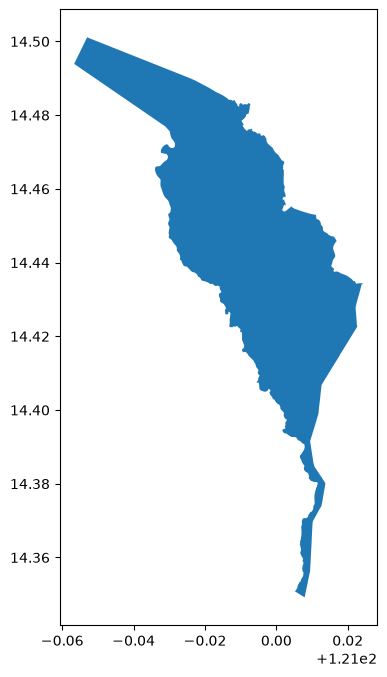

In [10]:
# ploting it to the screen
boundary.plot(figsize=(8, 8))

In [11]:
# getting roads

roads = ox.graph_from_place(city, network_type="all")

In [26]:
# it's a class networkx
roads

In [24]:
nodes, edges = ox.graph_to_gdfs(roads)

In [36]:
keys = nodes.keys()

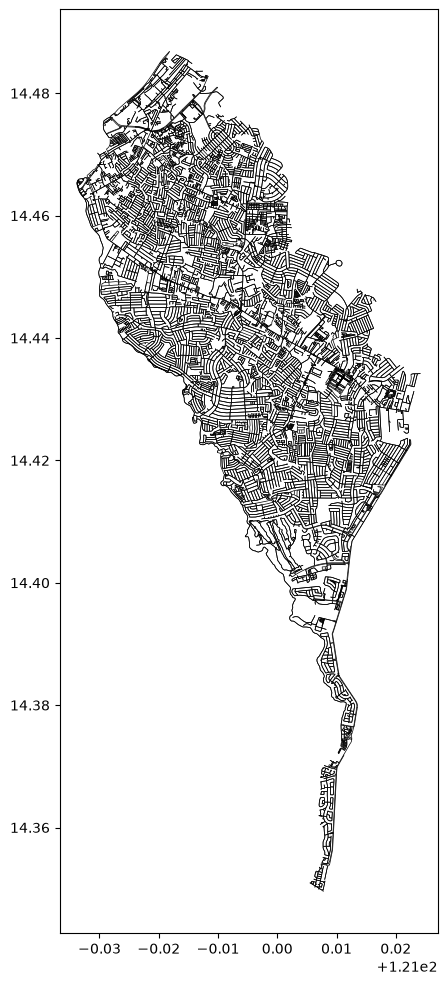

In [25]:
# ploting it to the screen
fig, ax = plt.subplots(figsize=(12, 12))

edges.plot(
    ax=ax,
    linewidth=0.5,
    color="black"
)

plt.show()

In [56]:
edges["highway"]

u            v            key
27150565     5207745007   0        secondary
             33576260     0      residential
             2602381764   0        secondary
             8651010550   0      residential
27150566     8647025981   0        secondary
                                    ...     
13946550161  13946550140  0         corridor
             13946550151  0         corridor
13987576886  1572821304   0          footway
14017194870  494754092    0          service
             8642853149   0          service
Name: highway, Length: 22657, dtype: object

In [57]:
edges["highway"].value_counts()

highway
residential                     14263
service                          3813
tertiary                         1461
footway                           872
secondary                         755
trunk                             513
unclassified                      300
primary                           214
corridor                          108
path                               76
pedestrian                         70
[service, residential]             32
[steps, footway]                   32
primary_link                       14
secondary_link                     14
[service, footway]                 14
[footway, corridor]                14
[steps, corridor]                  14
track                              14
[residential, footway]             10
steps                               8
cycleway                            8
[residential, path]                 6
trunk_link                          6
tertiary_link                       5
[footway, path]                     4
[pat

In [58]:
edges.explode("highway")["highway"].value_counts()

highway
residential       14313
service            3864
tertiary           1461
footway             952
secondary           755
trunk               513
unclassified        302
primary             214
corridor            138
path                 90
pedestrian           70
steps                58
primary_link         14
secondary_link       14
track                14
cycleway              8
trunk_link            6
tertiary_link         5
motorway_link         3
motorway              2
living_street         2
Name: count, dtype: int64

In [63]:
major_roads = edges [
    edges["highway"].isin([
        "motorway",
        "trunk",
        "primary",
        "secondary"
    ])
]

In [64]:
major_roads

osmid    highway lanes  \
u           v           key                                            
27150565    5207745007  0                 254443854  secondary     2   
            2602381764  0                 254443854  secondary     2   
27150566    8647025981  0                 254443854  secondary     2   
            33531847    0                 254443854  secondary     2   
27150567    33576212    0                 254443854  secondary     2   
...                                             ...        ...   ...   
13064513195 13064513182 0    [90113894, 1159368111]  secondary     4   
13098657437 412836209   0                 158467708    primary     4   
            1629123791  0                 158467708    primary     4   
13098657449 1629123791  0                 158467708    primary     4   
            32162202    0                 158467708    primary     4   

                                                        name  oneway reversed  \
u           v           key                                                     
27150565    5207745007  0              Marcos Alvarez Avenue   False    False   
            2602381764  0              Marcos Alvarez Avenue   False     True   
27150566    8647025981  0              Marcos Alvarez Avenue   False    False   
            33531847    0              Marcos Alvarez Avenue   False     True   
27150567    33576212    0              Marcos Alvarez Avenue   False    False   
...                                                      ...     ...      ...   
13064513195 13064513182 0    [J. Tionquiao Street, CAA Road]   False     True   
13098657437 412836209   0               P. Diego Cera Avenue   False    False   
            1629123791  0               P. Diego Cera Avenue   False     True   
13098657449 1629123791  0               P. Diego Cera Avenue   False    False   
            32162202    0               P. Diego Cera Avenue   False     True   

                                length  \
u           v           key              
27150565    5207745007  0     9.072832   
            2602381764  0    26.567372   
27150566    8647025981  0    25.022806   
            33531847    0    73.482234   
27150567    33576212    0    47.673954   
...                                ...   
13064513195 13064513182 0    78.214329   
13098657437 412836209   0    18.655531   
            1629123791  0    14.084635   
13098657449 1629123791  0     7.094351   
            32162202    0     5.965311   

                                                                      geometry  \
u           v           key                                                      
27150565    5207745007  0    LINESTRING (120.99132 14.41768, 120.9914 14.41...   
            2602381764  0    LINESTRING (120.99132 14.41768, 120.99122 14.4...   
27150566    8647025981  0    LINESTRING (120.99244 14.4173, 120.99264 14.41...   
            33531847    0    LINESTRING (120.99244 14.4173, 120.99223 14.41...   
27150567    33576212    0    LINESTRING (120.99378 14.41658, 120.99419 14.4...   
...                                                                        ...   
13064513195 13064513182 0    LINESTRING (120.99568 14.46275, 120.99562 14.4...   
13098657437 412836209   0     LINESTRING (120.97125 14.46989, 120.97139 14.47)   
            1629123791  0    LINESTRING (120.97125 14.46989, 120.97121 14.4...   
13098657449 1629123791  0    LINESTRING (120.9711 14.46977, 120.97115 14.46...   
            32162202    0    LINESTRING (120.9711 14.46977, 120.97106 14.46...   

                            service access width  ref maxspeed bridge tunnel  \
u           v           key                                                    
27150565    5207745007  0       NaN    NaN   NaN  NaN      NaN    NaN    NaN   
            2602381764  0       NaN    NaN   NaN  NaN      NaN    NaN    NaN   
27150566    8647025981  0       NaN    NaN   NaN  NaN      NaN    NaN    NaN   
            33531847    0       NaN    Na

In [62]:
major_roads.plot(
    ax=ax,
    linewidth=1,
    color="black"
)

<Axes: >

<Axes: >

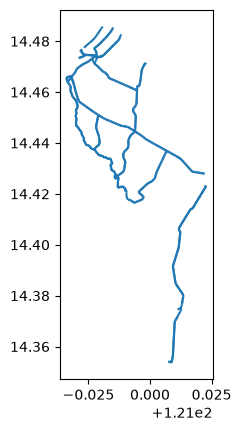

In [65]:
major_roads.plot()

In [16]:

# getting tags from OSM for the location
tags = {"boundary": "administrative", "admin_level": "10"}

# getting osm data for the location that matches the tags
gdf = ox.features_from_place("Las Piñas, Philippines", tags=tags)

# printing it to the screen
gdf.head()

geometry admin_level          name  \
element id                                                                 
node    255071874    POINT (121.00865 14.4209)          10         Pilar   
        3720664827  POINT (120.97036 14.45855)          10  Pamplona Uno   
        3720664854  POINT (120.98462 14.48307)          10    Manuyo Uno   
        3720664856  POINT (120.98062 14.47806)          10         Ilaya   
        3720664857  POINT (120.97828 14.47798)          10  Elias Aldana   

                   name:en name:ja name:ko name:tl    old_ref    place  \
element id                                                               
node    255071874      NaN     NaN     NaN     NaN  137601015  quarter   
        3720664827     NaN     NaN     NaN     NaN  137601006  quarter   
        3720664854     NaN     NaN     NaN     NaN  137601005  quarter   
        3720664856     NaN     NaN     NaN     NaN  137601004  quarter   
        3720664857     NaN     NaN     NaN     NaN  137601003  quarter   

                   population  ... type related_law barrier maritime landuse  \
element id                     ...                                             
node    255071874       31420  ...  NaN         NaN     NaN      NaN     NaN   
        3720664827      19658  ...  NaN         NaN     NaN      NaN     NaN   
        3720664854      13908  ...  NaN         NaN     NaN      NaN     NaN   
        3720664856       7287  ...  NaN         NaN     NaN      NaN     NaN   
        3720664857      11758  ...  NaN         NaN     NaN      NaN     NaN   

                   addr2:street border_type name:zh-Latn-pinyin  \
element id                                                        
node    255071874           NaN         NaN                 NaN   
        3720664827          NaN         NaN                 NaN   
        3720664854          NaN         NaN                 NaN   
        3720664856          NaN         NaN                 NaN   
        3720664857          NaN         NaN                 NaN   

                   population:source land_area  
element id                                      
node    255071874                NaN       NaN  
        3720664827               NaN       NaN  
        3720664854               NaN       NaN  
        3720664856               NaN       NaN  
        3720664857               NaN       NaN  

[5 rows x 76 columns]